In [1]:
from cme.diffusion_models import diffusion as dd
import pandas as pd
import numpy as np
from cme.utils import common_utils as ut
import arviz as az
import os

In [2]:
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


cpu


In [3]:
rotation_RT = pd.read_csv(f"data/rotation_rt.csv")
#rotation_RT = pd.read_csv(f"data/sim_low_low_500_rt.csv")
rotation_RT_n = rotation_RT.loc[~rotation_RT.isna().any(axis=1),:].to_numpy()#[0:1,:]

rotation_X = pd.read_csv(f"data/rotation_ra.csv")
#rotation_X = pd.read_csv(f"data/sim_low_low_500_ra.csv")
rotation_X_n = rotation_X.loc[~rotation_RT.isna().any(axis=1),:].astype(int).to_numpy()#[0:1,:]

In [4]:
rotation_RT_n[rotation_RT_n < 0.9]

array([0.839, 0.756, 0.882, 0.821, 0.689, 0.858, 0.878, 0.882, 0.735,
       0.724])

In [5]:
samples_n, tune, chains, acceptance_rate = 2000, 2000, 4,0.85

posterior_chain,_ = dd.sample_posterior_params(rotation_RT_n, rotation_X_n, 
samples_n,chains=chains, sampler="PYMC", tune=tune, acceptance_rate = acceptance_rate)


2023-04-05 11:53:08,232 - Common-Utils - DEBUG - [m, s, v_pr, a_pr, z_pr, t_er_pr]


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [m, s, v_pr, a_pr, z_pr, t_er_pr]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 473 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 8000 divergences after tuning. Increase `target_accept` or reparameterize.


In [6]:
posterior_chain

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

In [7]:
df_posterior_chain = ut.get_summary(posterior_chain)
df_posterior_chain

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,var_name,var_idx
0,0.068,0.291,-0.365,0.415,0.145,0.111,4.0,15.0,4.79,m,0]
1,0.129,0.596,-0.620,0.834,0.298,0.228,4.0,4.0,8.94,m,1]
2,-0.068,0.560,-0.845,0.497,0.279,0.214,4.0,11.0,4.53,m,2]
3,0.404,0.389,-0.078,0.890,0.194,0.149,4.0,27.0,7.37,m,3]
4,0.072,0.460,-0.369,0.775,0.229,0.176,4.0,4.0,8.74,s,0]
...,...,...,...,...,...,...,...,...,...,...,...
383,0.058,0.578,-0.614,0.982,0.289,0.221,4.0,4.0,8.34,t_er_pr,"90, 0]"
384,-0.108,0.577,-0.844,0.765,0.288,0.220,4.0,15.0,9.74,t_er_pr,"91, 0]"
385,0.080,0.525,-0.623,0.763,0.262,0.201,4.0,4.0,7.20,t_er_pr,"92, 0]"
386,0.022,0.383,-0.351,0.646,0.191,0.146,4.0,4.0,13.10,t_er_pr,"93, 0]"


In [8]:
r_hat = ut.get_rhat(df_posterior_chain)
r_hat

,0,1,2,3,4,5,6,7,8,9,...,378,379,380,381,382,383,384,385,386,387
r_hat,4.79,8.94,4.53,7.37,8.74,3.99,8.46,5.0,4.63,3.91,...,8.41,7.86,7.09,8.24,4.93,8.34,9.74,7.2,13.1,4.89


/home/rkm160630/anaconda3/envs/ds2/lib/python3.11/site-packages/arviz/stats/density_utils.py:487: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/rkm160630/anaconda3/envs/ds2/lib/python3.11/site-packages/arviz/stats/density_utils.py:487: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/rkm160630/anaconda3/envs/ds2/lib/python3.11/site-packages/arviz/stats/density_utils.py:487: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/rkm160630/anaconda3/envs/ds2/lib/python3.11/site-packages/arviz/stats/density_utils.py:487: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite v

array([[<Axes: title={'center': 'm'}>, <Axes: title={'center': 'm'}>],
       [<Axes: title={'center': 's'}>, <Axes: title={'center': 's'}>],
       [<Axes: title={'center': 'v_pr'}>,
        <Axes: title={'center': 'v_pr'}>],
       [<Axes: title={'center': 'a_pr'}>,
        <Axes: title={'center': 'a_pr'}>],
       [<Axes: title={'center': 'z_pr'}>,
        <Axes: title={'center': 'z_pr'}>],
       [<Axes: title={'center': 't_er_pr'}>,
        <Axes: title={'center': 't_er_pr'}>]], dtype=object)

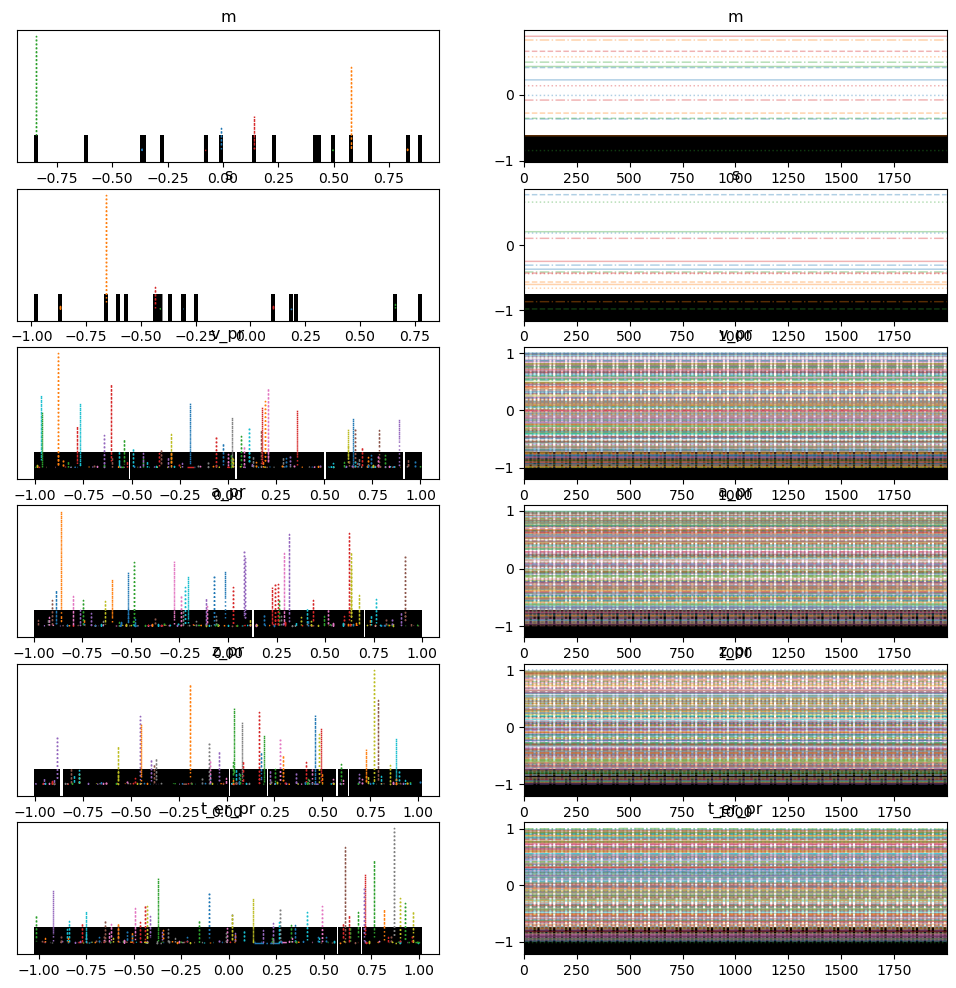

In [15]:
az.plot_trace(posterior_chain)

In [10]:
#posterior_chain = posterior_chain.sel(chain=[0,2,3])

In [11]:
az.summary(posterior_chain)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
m[0],0.068,0.291,-0.365,0.415,0.145,0.111,4.0,15.0,4.79
m[1],0.129,0.596,-0.620,0.834,0.298,0.228,4.0,4.0,8.94
m[2],-0.068,0.560,-0.845,0.497,0.279,0.214,4.0,11.0,4.53
m[3],0.404,0.389,-0.078,0.890,0.194,0.149,4.0,27.0,7.37
s[0],0.072,0.460,-0.369,0.775,0.229,0.176,4.0,4.0,8.74
...,...,...,...,...,...,...,...,...,...
"t_er_pr[90, 0]",0.058,0.578,-0.614,0.982,0.289,0.221,4.0,4.0,8.34
"t_er_pr[91, 0]",-0.108,0.577,-0.844,0.765,0.288,0.220,4.0,15.0,9.74
"t_er_pr[92, 0]",0.080,0.525,-0.623,0.763,0.262,0.201,4.0,4.0,7.20
"t_er_pr[93, 0]",0.022,0.383,-0.351,0.646,0.191,0.146,4.0,4.0,13.10


<Axes: ylabel='Density'>

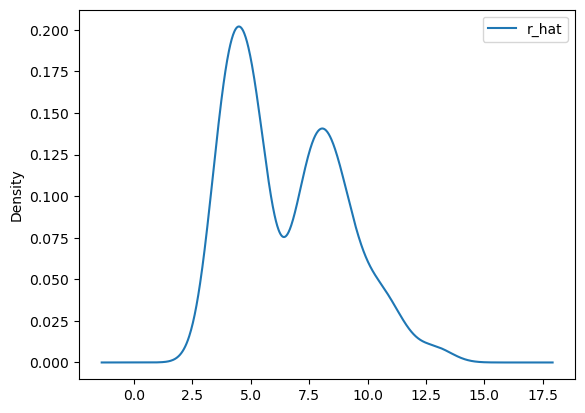

In [12]:
r_hat.T.plot(kind="kde")

In [13]:
#az.plot_trace(posterior_chain)

In [14]:
v_c_ch = ut.get_chains_for_param(posterior_chain,"v")
v_c_ch

KeyError: 'v'

In [ ]:
v_c_ch.plot(kind="box")

In [ ]:
a_c_ch = ut.get_chains_for_param(posterior_chain,"a")
a_c_ch

In [ ]:
a_c_ch.fillna(0).plot(kind="box")

In [ ]:
z_c_ch = ut.get_chains_for_param(posterior_chain,"z")
z_c_ch

In [ ]:
z_c_ch.fillna(0).plot(kind="box")

In [ ]:
ter_c_ch = ut.get_chains_for_param(posterior_chain,"t_er")
ter_c_ch

In [ ]:
ter_c_ch.fillna(0).plot(kind="box")